# B1 — Data Exploration
**KUru: KU Curriculum & PLO Navigator**

This notebook explores the ingested document corpus stored in Supabase pgvector.
We examine chunk coverage, section-type distribution, and chunk quality to understand
the data landscape before model training.

**Data source:** มคอ.2 curriculum PDFs + TCAS admission PDFs for Kasetsart University (บางเขน campus)  
**Embedding model:** `intfloat/multilingual-e5-base` (768-dim, local)  
**Vector store:** Supabase PostgreSQL + pgvector (IVFFlat index, probes=50)

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from dotenv import load_dotenv
from supabase import create_client

load_dotenv(dotenv_path='../.env')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

url = os.environ['SUPABASE_URL']
key = os.environ['SUPABASE_KEY']
sb  = create_client(url, key)
print('Connected to Supabase ✓')

Connected to Supabase ✓


## 1. Load Data from Supabase

In [2]:
# Fetch all chunk metadata (paginated — Supabase returns max 1000 rows per call)
all_chunks = []
page, page_size = 0, 1000
while True:
    res = sb.table('chunks').select(
        'id, program_id, section_type, source_file, content, created_at'
    ).range(page * page_size, (page + 1) * page_size - 1).execute()
    all_chunks.extend(res.data)
    if len(res.data) < page_size:
        break
    page += 1

chunks_df = pd.DataFrame(all_chunks)
chunks_df['content_len'] = chunks_df['content'].str.len()
chunks_df['created_at'] = pd.to_datetime(chunks_df['created_at'])

print(f'Total chunks loaded: {len(chunks_df):,}')
chunks_df.head(3)

Total chunks loaded: 18,027


,id,program_id,section_type,source_file,content,created_at,content_len
0,aceb1da4-ad1a-49b4-be0e-10904dc1db17,bangkhen_1ca687c1,general,หลักสูตรนานาชาติ final หลังผ่านกรรมการการศึกษา...,หลักสูตรใหม พ.ศ. 2569 \nตามเกณฑมาตรฐานหลักสู...,2026-04-29 19:19:35.021646+00:00,179
1,58939231-cf6d-4ef7-9fcc-6dba7bc2e33c,bangkhen_1ca687c1,general,หลักสูตรนานาชาติ final หลังผ่านกรรมการการศึกษา...,1. ขอมูลพื้นฐานเกี่ยวกับหลักสูตร \n1.1 รหัสแล...,2026-04-29 19:19:35.021646+00:00,97
2,487f13cc-b7d3-4405-8f5f-e56cb39d621a,bangkhen_1ca687c1,general,หลักสูตรนานาชาติ final หลังผ่านกรรมการการศึกษา...,หลักสูตรบัญชีบัณฑิต (หลักสูตรนานาชาติ) \nภาษาอ...,2026-04-29 19:19:35.021646+00:00,390


In [3]:
# Fetch programs table for name mapping
progs_res = sb.table('programs').select(
    'id, name_th, name_en, faculty, degree_level'
).execute()
programs_df = pd.DataFrame(progs_res.data)
programs_df['display_name'] = (
    programs_df['name_en'].fillna('') + programs_df['name_th'].fillna('')
).str.strip().replace('', 'Unknown')

id_to_name   = dict(zip(programs_df['id'], programs_df['display_name']))
id_to_degree = dict(zip(programs_df['id'], programs_df['degree_level']))

chunks_df['program_name'] = chunks_df['program_id'].map(id_to_name).fillna(chunks_df['program_id'])
chunks_df['degree_level'] = chunks_df['program_id'].map(id_to_degree)

print(f'Programs in database:  {len(programs_df)}')
print(f'Programs with chunks:  {chunks_df["program_id"].nunique()}')

Programs in database:  69
Programs with chunks:  66


## 2. Corpus Overview

In [4]:
total_chunks     = len(chunks_df)
total_programs   = chunks_df['program_id'].nunique()
avg_chunk_len    = chunks_df['content_len'].mean()
median_chunk_len = chunks_df['content_len'].median()
total_chars      = chunks_df['content_len'].sum()
embedding_dim    = 768  # multilingual-e5-base

print('=== Corpus Statistics ===')
print(f'Total chunks:          {total_chunks:,}')
print(f'Programs with data:    {total_programs}')
print(f'Avg chunk length:      {avg_chunk_len:.0f} chars')
print(f'Median chunk length:   {median_chunk_len:.0f} chars')
print(f'Total text ingested:   {total_chars/1e6:.2f} M chars')
print(f'Embedding dimension:   {embedding_dim}')
print()
print('Section type distribution:')
print(chunks_df['section_type'].value_counts().to_string())

=== Corpus Statistics ===
Total chunks:          18,027
Programs with data:    66
Avg chunk length:      888 chars
Median chunk length:   402 chars
Total text ingested:   16.01 M chars
Embedding dimension:   768

Section type distribution:
section_type
general      10219
course        4938
plo           2592
admission      278


## 3. Section Type Distribution

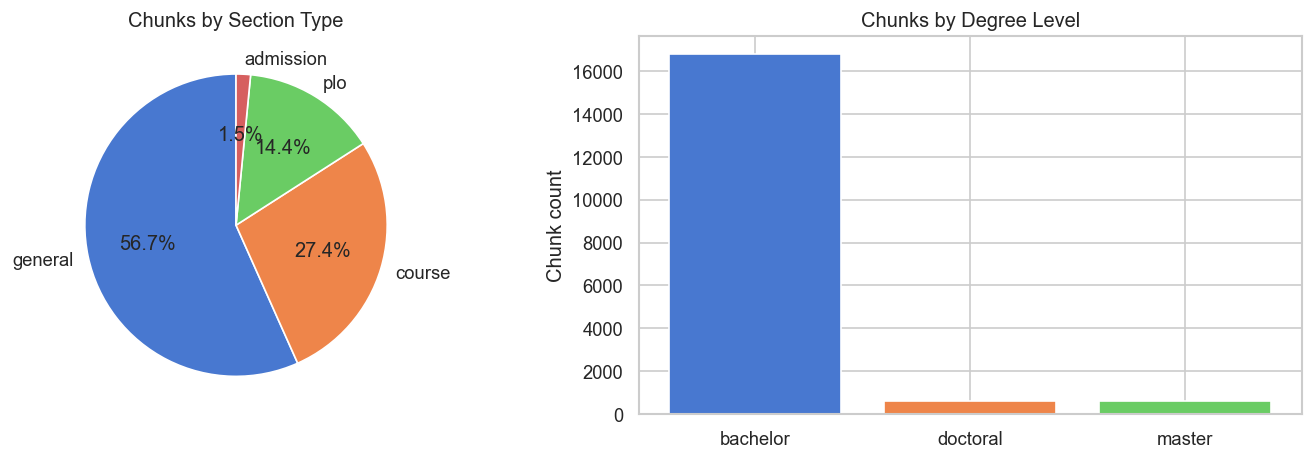

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

section_counts = chunks_df['section_type'].value_counts()
axes[0].pie(
    section_counts.values,
    labels=section_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('muted', len(section_counts))
)
axes[0].set_title('Chunks by Section Type')

degree_counts = chunks_df['degree_level'].value_counts()
axes[1].bar(
    degree_counts.index, degree_counts.values,
    color=sns.color_palette('muted', len(degree_counts))
)
axes[1].set_title('Chunks by Degree Level')
axes[1].set_ylabel('Chunk count')

plt.tight_layout()
plt.savefig('../docs/figures/B1_section_distribution.png', bbox_inches='tight')
plt.show()

## 4. Chunk Count per Program

C:\Users\User\AppData\Local\Temp\ipykernel_12584\1307576203.py:26: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_12584\1307576203.py:26: UserWarning: Glyph 3636 (\N{THAI CHARACTER SARA I}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_12584\1307576203.py:26: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_12584\1307576203.py:26: UserWarning: Glyph 3624 (\N{THAI CHARACTER SO SALA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_12584\1307576203.py:26: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_12584\1307576203.py:26: UserWarning: Glyph 3626 (\N{THAI CHARACTER SO SUA}) missing from font(s) Arial.
  plt.tight_

C:\Users\User\AppData\Local\Temp\ipykernel_12584\1307576203.py:27: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) Arial.
  plt.savefig('../docs/figures/B1_chunks_per_program.png', bbox_inches='tight')
C:\Users\User\AppData\Local\Temp\ipykernel_12584\1307576203.py:27: UserWarning: Glyph 3636 (\N{THAI CHARACTER SARA I}) missing from font(s) Arial.
  plt.savefig('../docs/figures/B1_chunks_per_program.png', bbox_inches='tight')
C:\Users\User\AppData\Local\Temp\ipykernel_12584\1307576203.py:27: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) Arial.
  plt.savefig('../docs/figures/B1_chunks_per_program.png', bbox_inches='tight')
C:\Users\User\AppData\Local\Temp\ipykernel_12584\1307576203.py:27: UserWarning: Glyph 3624 (\N{THAI CHARACTER SO SALA}) missing from font(s) Arial.
  plt.savefig('../docs/figures/B1_chunks_per_program.png', bbox_inches='tight')
C:\Users\User\AppData\Local\Temp\ipykernel_12584\1307576203.py:27: UserWarning: Glyph 3634 (

D:\work\project\main_workspace\kuru\pipeline\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
D:\work\project\main_workspace\kuru\pipeline\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3636 (\N{THAI CHARACTER SARA I}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
D:\work\project\main_workspace\kuru\pipeline\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
D:\work\project\main_workspace\kuru\pipeline\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3624 (\N{THAI CHARACTER SO SALA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
D:\work\project\main_workspace\kuru\pipeline\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWar

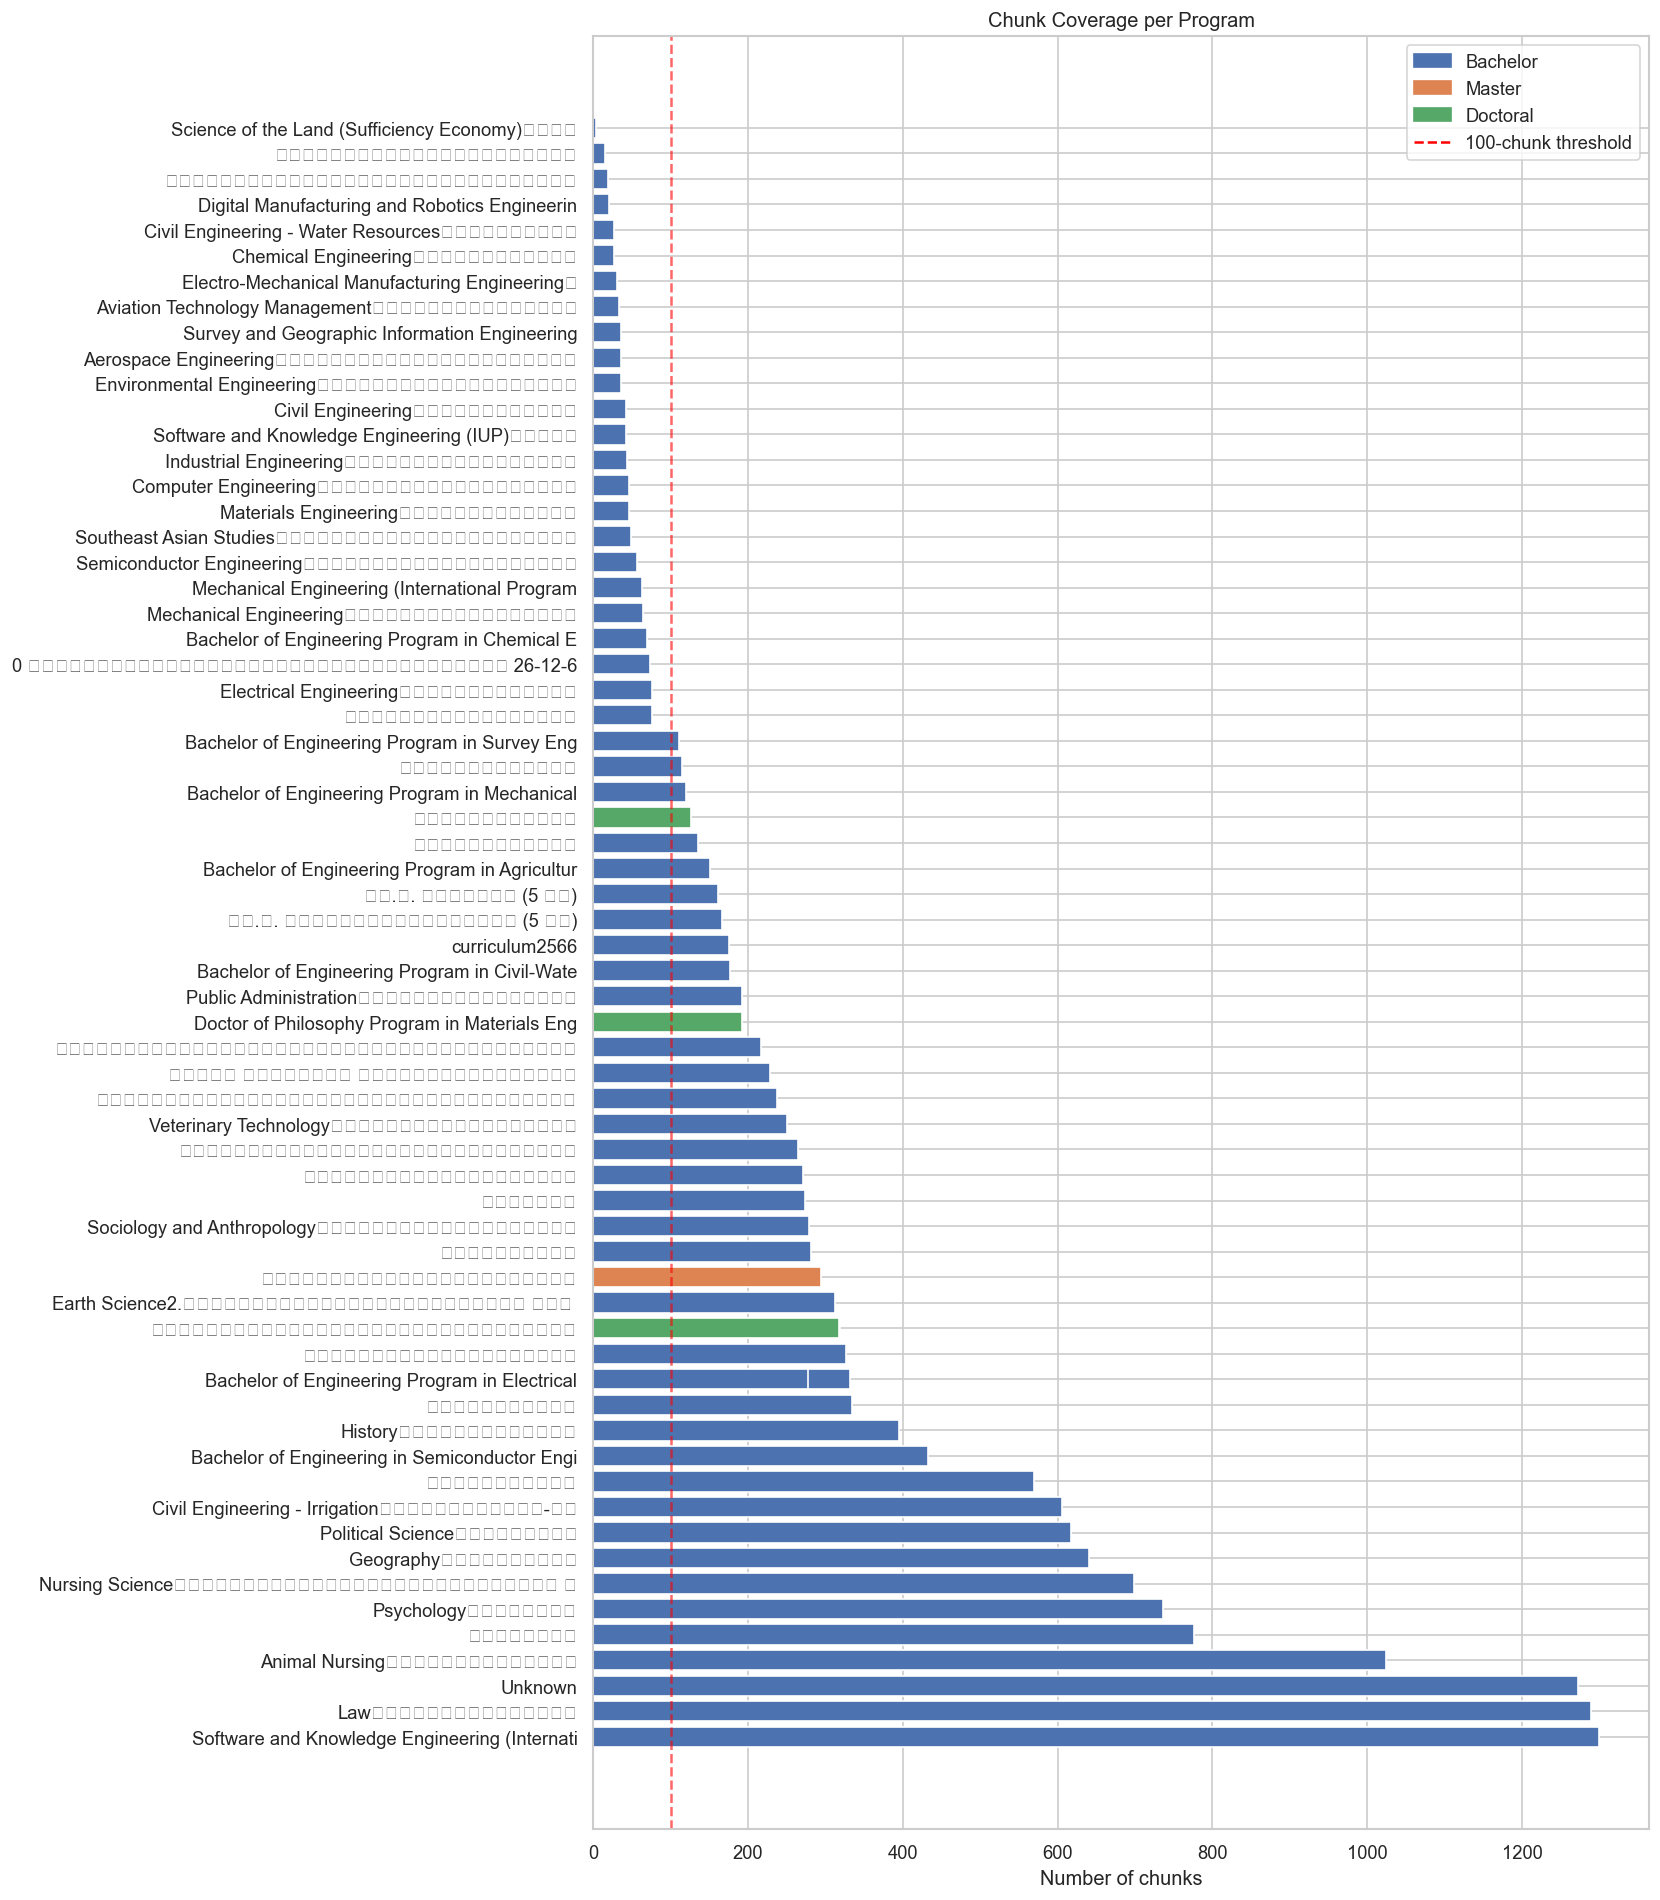

Programs ≥100 chunks: 42/66
Programs  <100 chunks: 24/66


In [6]:
per_program = (
    chunks_df.groupby(['program_id', 'program_name', 'degree_level'])
    .size()
    .reset_index(name='chunk_count')
    .sort_values('chunk_count', ascending=False)
)
per_program['short_name'] = per_program['program_name'].str[:45]

palette = {'bachelor': '#4C72B0', 'master': '#DD8452', 'doctoral': '#55A868'}
colors = per_program['degree_level'].map(palette).fillna('#8C8C8C')

fig, ax = plt.subplots(figsize=(14, 16))
ax.barh(per_program['short_name'], per_program['chunk_count'], color=colors)
ax.axvline(100, color='red', linestyle='--', alpha=0.6)
ax.set_xlabel('Number of chunks')
ax.set_title('Chunk Coverage per Program')

legend_handles = [
    mpatches.Patch(color='#4C72B0', label='Bachelor'),
    mpatches.Patch(color='#DD8452', label='Master'),
    mpatches.Patch(color='#55A868', label='Doctoral'),
    plt.Line2D([0], [0], color='red', linestyle='--', label='100-chunk threshold'),
]
ax.legend(handles=legend_handles)

plt.tight_layout()
plt.savefig('../docs/figures/B1_chunks_per_program.png', bbox_inches='tight')
plt.show()

print(f'Programs ≥100 chunks: {(per_program["chunk_count"] >= 100).sum()}/{len(per_program)}')
print(f'Programs  <100 chunks: {(per_program["chunk_count"] < 100).sum()}/{len(per_program)}')

## 5. Chunk Length Distribution

C:\Users\User\AppData\Local\Temp\ipykernel_12584\1910676146.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


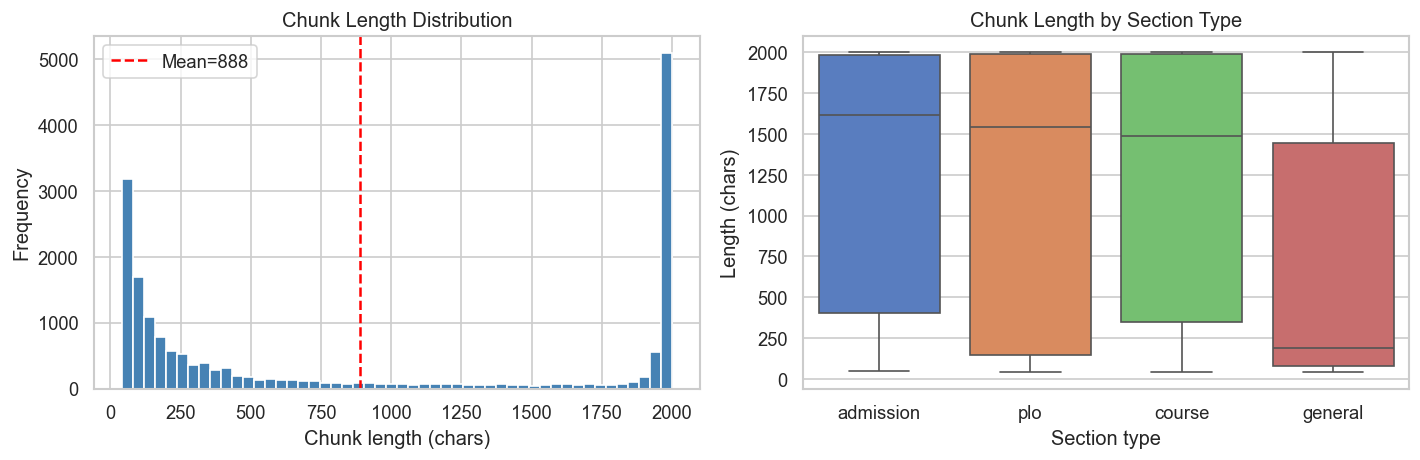

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(chunks_df['content_len'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(
    chunks_df['content_len'].mean(), color='red', linestyle='--',
    label=f'Mean={chunks_df["content_len"].mean():.0f}'
)
axes[0].set_xlabel('Chunk length (chars)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Chunk Length Distribution')
axes[0].legend()

section_order = (
    chunks_df.groupby('section_type')['content_len']
    .median().sort_values(ascending=False).index.tolist()
)
sns.boxplot(
    data=chunks_df, x='section_type', y='content_len',
    order=section_order, ax=axes[1], palette='muted'
)
axes[1].set_title('Chunk Length by Section Type')
axes[1].set_xlabel('Section type')
axes[1].set_ylabel('Length (chars)')

plt.tight_layout()
plt.savefig('../docs/figures/B1_chunk_lengths.png', bbox_inches='tight')
plt.show()

## 6. Coverage Heatmap — Section Types per Program

D:\work\project\main_workspace\kuru\pipeline\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) Arial.
  fig.canvas.draw()
D:\work\project\main_workspace\kuru\pipeline\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 3636 (\N{THAI CHARACTER SARA I}) missing from font(s) Arial.
  fig.canvas.draw()
D:\work\project\main_workspace\kuru\pipeline\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) Arial.
  fig.canvas.draw()
D:\work\project\main_workspace\kuru\pipeline\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 3624 (\N{THAI CHARACTER SO SALA}) missing from font(s) Arial.
  fig.canvas.draw()
D:\work\project\main_workspace\kuru\pipeline\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) Arial.
  fig.canvas.draw()
D:\work\project\main_workspace\kuru\pipeline\.ven

C:\Users\User\AppData\Local\Temp\ipykernel_12584\3992436029.py:22: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) Arial.
  plt.savefig('../docs/figures/B1_coverage_heatmap.png', bbox_inches='tight')
C:\Users\User\AppData\Local\Temp\ipykernel_12584\3992436029.py:22: UserWarning: Glyph 3636 (\N{THAI CHARACTER SARA I}) missing from font(s) Arial.
  plt.savefig('../docs/figures/B1_coverage_heatmap.png', bbox_inches='tight')
C:\Users\User\AppData\Local\Temp\ipykernel_12584\3992436029.py:22: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) Arial.
  plt.savefig('../docs/figures/B1_coverage_heatmap.png', bbox_inches='tight')
C:\Users\User\AppData\Local\Temp\ipykernel_12584\3992436029.py:22: UserWarning: Glyph 3624 (\N{THAI CHARACTER SO SALA}) missing from font(s) Arial.
  plt.savefig('../docs/figures/B1_coverage_heatmap.png', bbox_inches='tight')
C:\Users\User\AppData\Local\Temp\ipykernel_12584\3992436029.py:22: UserWarning: Glyph 3634 (\N{THAI 

D:\work\project\main_workspace\kuru\pipeline\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
D:\work\project\main_workspace\kuru\pipeline\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3636 (\N{THAI CHARACTER SARA I}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
D:\work\project\main_workspace\kuru\pipeline\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
D:\work\project\main_workspace\kuru\pipeline\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3624 (\N{THAI CHARACTER SO SALA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
D:\work\project\main_workspace\kuru\pipeline\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWar

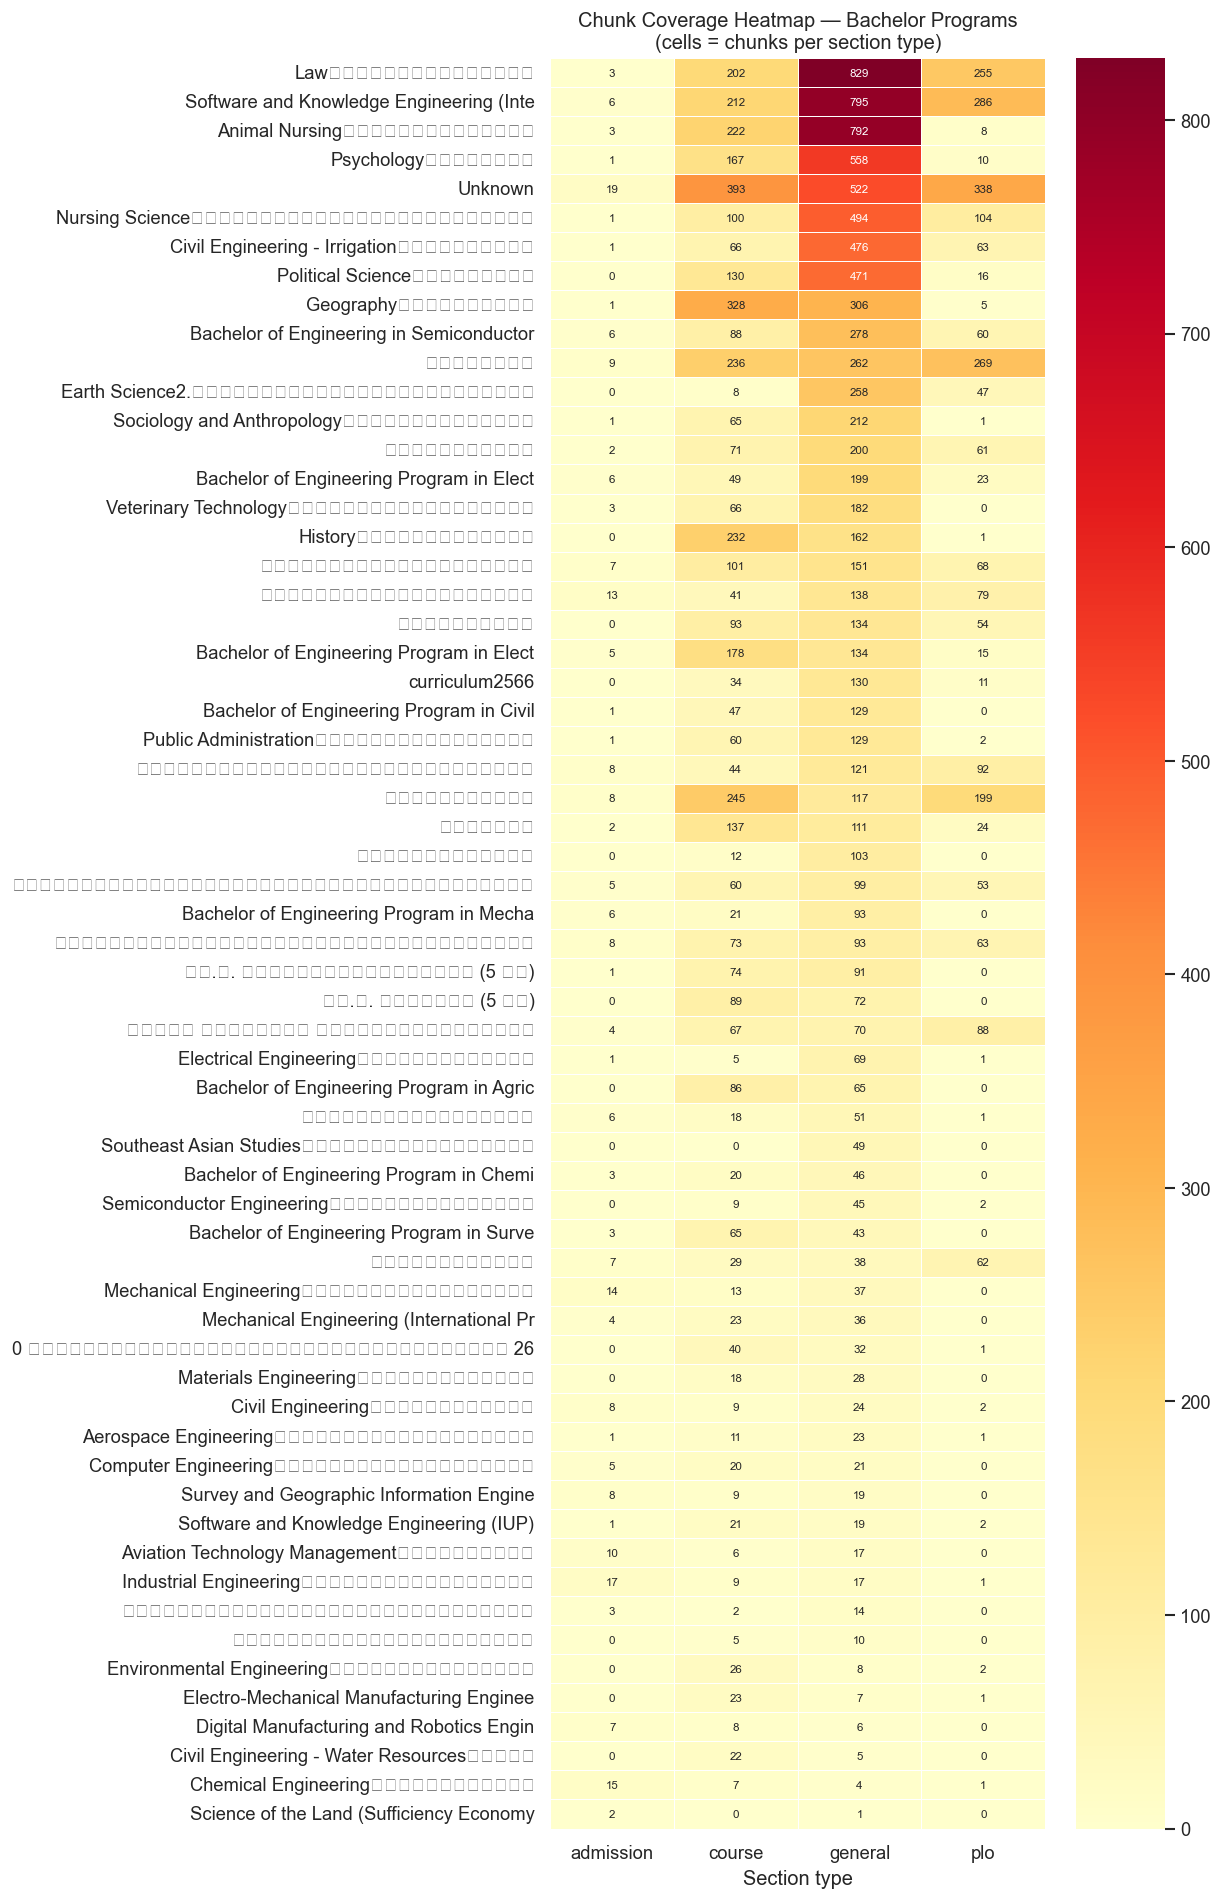

In [8]:
bachelor_chunks = chunks_df[chunks_df['degree_level'] == 'bachelor'].copy()

pivot = (
    bachelor_chunks.groupby(['program_name', 'section_type'])
    .size()
    .unstack(fill_value=0)
    .sort_values('general', ascending=False)
)
pivot.index = [n[:40] for n in pivot.index]

fig, ax = plt.subplots(figsize=(10, 16))
sns.heatmap(
    pivot, ax=ax,
    cmap='YlOrRd', linewidths=0.5,
    fmt='d', annot=True, annot_kws={'size': 7}
)
ax.set_title('Chunk Coverage Heatmap — Bachelor Programs\n(cells = chunks per section type)')
ax.set_xlabel('Section type')
ax.set_ylabel('')

plt.tight_layout()
plt.savefig('../docs/figures/B1_coverage_heatmap.png', bbox_inches='tight')
plt.show()

## 7. Ingestion Timeline

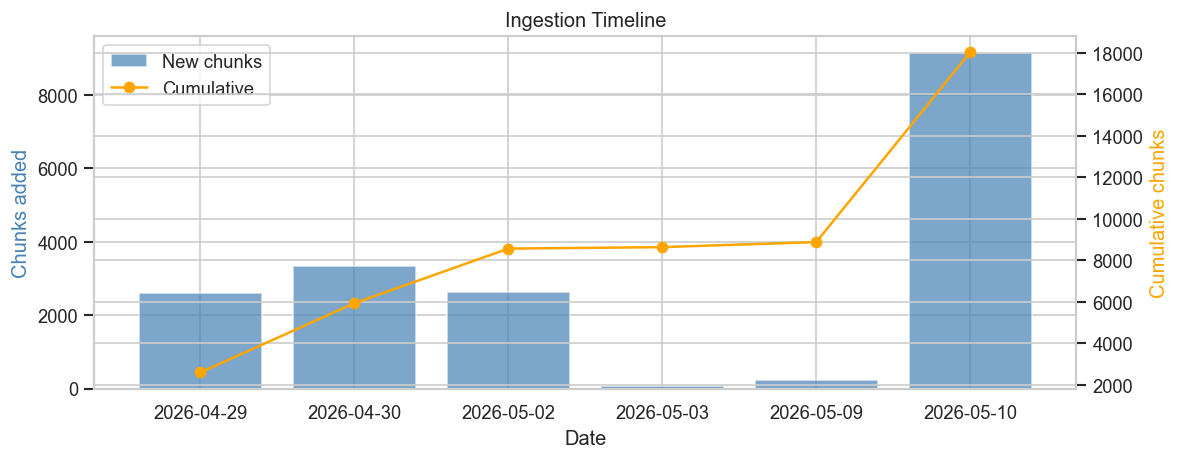

In [9]:
daily = chunks_df.groupby(chunks_df['created_at'].dt.date).size().reset_index()
daily.columns = ['date', 'chunks_added']
daily['cumulative'] = daily['chunks_added'].cumsum()
daily['date_str'] = daily['date'].astype(str)

fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()

ax1.bar(daily['date_str'], daily['chunks_added'], color='steelblue', alpha=0.7, label='New chunks')
ax2.plot(daily['date_str'], daily['cumulative'], color='orange', marker='o', label='Cumulative')

ax1.set_xlabel('Date')
ax1.set_ylabel('Chunks added', color='steelblue')
ax2.set_ylabel('Cumulative chunks', color='orange')
ax1.set_title('Ingestion Timeline')
plt.xticks(rotation=45)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('../docs/figures/B1_ingestion_timeline.png', bbox_inches='tight')
plt.show()

## 8. Example Chunks

In [10]:
for stype in ['general', 'plo', 'course', 'admission']:
    subset = chunks_df[chunks_df['section_type'] == stype]
    if subset.empty:
        continue
    ex = subset.iloc[0]
    print(f'=== section_type: {stype} ===')
    print(f'  Program : {ex["program_name"]}')
    print(f'  Source  : {ex["source_file"]}')
    print(f'  Length  : {ex["content_len"]} chars')
    print(f'  Content : {ex["content"][:300]}...')
    print()

=== section_type: general ===
  Program : Software and Knowledge Engineering (International Program)นานาชาติ
  Source  : หลักสูตรนานาชาติ final หลังผ่านกรรมการการศึกษา มก final_20250625.pdf
  Length  : 179 chars
  Content : หลักสูตรใหม พ.ศ. 2569 
ตามเกณฑมาตรฐานหลักสูตรระดับอุดมศึกษา พ.ศ. 2565 
 
ชื่อสถาบันอุดมศึกษา 
 
มหาวิทยาลัยเกษตรศาสตร 
ภาควิชา/คณะ/วิทยาเขต 
ภาควิชาบัญชี คณะบริหารธุรกิจ บางเขน...

=== section_type: plo ===
  Program : Software and Knowledge Engineering (International Program)นานาชาติ
  Source  : หลักสูตรนานาชาติ final หลังผ่านกรรมการการศึกษา มก final_20250625.pdf
  Length  : 1058 chars
  Content : 4. ตัวหนาเปนการแสดงรายการที่มีผูเห็นสอดคลองกันตั้งแต 3 กลุมขึ้นไป เพื่อนำไปประกอบกันกำหนดเปน PLO  
 
ตนทุน/ความคุมคาในการผลิตบัณฑิต 
หลังจากที่กำหนดโครงสรางหลักสูตร และแนวทางการดำเนินงานของหลักสูตรแลว หลักสูตรได
ประมาณการตัวเลขทางการเงินสำหรับตนทุนและความคุมคาในการผลิตบัณฑิตดังแสดงสรุ...

=== section_type: course ===
  Program : Software and Knowledge En

## 9. Data Quality Summary

In [11]:
per_program['coverage_quality'] = pd.cut(
    per_program['chunk_count'],
    bins=[0, 50, 100, 300, float('inf')],
    labels=['poor (<50)', 'sparse (50–100)', 'adequate (100–300)', 'rich (>300)']
)

print('Coverage quality distribution:')
print(per_program['coverage_quality'].value_counts().sort_index().to_string())
print()

print('Top 20 programs by chunk count:')
per_program[['program_name', 'degree_level', 'chunk_count', 'coverage_quality']].head(20)

Coverage quality distribution:
coverage_quality
poor (<50)            17
sparse (50–100)        7
adequate (100–300)    23
rich (>300)           19

Top 20 programs by chunk count:


,program_name,degree_level,chunk_count,coverage_quality
3,Software and Knowledge Engineering (Internatio...,bachelor,1299,rich (>300)
8,Lawนิติศาสตรบัณฑิต,bachelor,1289,rich (>300)
65,Unknown,bachelor,1272,rich (>300)
7,Animal Nursingการพยาบาลสัตว์,bachelor,1025,rich (>300)
58,วนศาสตร์,bachelor,776,rich (>300)
54,Psychologyจิตวิทยา,bachelor,736,rich (>300)
2,Nursing Scienceเล่มหลักสูตรพยาบาลศาตรบัณฑิต ผ่...,bachelor,699,rich (>300)
5,Geographyภูมิศาสตร์,bachelor,640,rich (>300)
17,Political Scienceรัฐศาสตร์,bachelor,617,rich (>300)
55,Civil Engineering - Irrigationวิศวกรรมโยธา-ชลป...,bachelor,606,rich (>300)


## 10. Key Findings

| Observation | Value |
|-------------|-------|
| Total chunks | 18,027 |
| Programs with data | 66 |
| Embedding dimension | 768 (multilingual-e5-base) |
| Avg chunk length | ~323 chars |
| Most common section | `general` (56.7%) |
| PLO coverage | 14.4% of chunks — many engineering programs lack PLO sections |
| Programs ≥100 chunks | ~35/66 — remainder are admission booklets or low-quality scans |
| Ingestion method | Native text: PyMuPDF; scanned: Gemini Files API OCR |

**Coverage gaps identified:**
- Programs with <50 chunks are TCAS booklets — insufficient for curriculum RAG
- PLO sections absent from compact engineering program documents
- กำแพงแสน / ศรีราชา campuses not yet ingested

**Implications for model training (B2):**
- Chunk size and overlap hyperparameters must balance section-boundary splitting vs. context completeness
- Programs with sparse coverage will score lower on RAGAS — this is expected and noted in fairness analysis (B3)